# Stagev6 External-Test-First Result Audit

This notebook audits existing Stagev6 result files only. It does not train models, call APIs, re-extract features, or modify model, prediction, feature, or training-result files.

Display priority is fixed:

1. external accuracy
2. external confusion matrix / TP, TN, FP, FN
3. external sensitivity and specificity
4. external route diagnostics
5. external subgroup performance
6. bootstrap external accuracy CI
7. CV results as secondary consistency audit only


## 0. Experiment identity and audit

Stagev6 core structure:

```text
late gate -> direct AD
non-late -> E+M AD/control branch
```

This section reports experiment identity, file availability, sample counts, feature source manifest, and leakage check status. It intentionally does not discuss model performance ranking.


In [7]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 110)

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run_stagev6.py").exists()), Path.cwd())
OUT = ROOT / "output"
FINAL = OUT / "final_report"
FIG_DIR = FINAL / "notebook_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_EXTERNAL_N = 71
EXPECTED_CASCADE_COUNT = 144
EXPECTED_GROUPS = ["control", "early", "middle", "late", "AD_high_MMSE"]

REQUIRED_FILES = {
    "ranking": "stagev6_model_ranking_by_external_accuracy.csv",
    "external_performance": "stagev6_external_performance_report.csv",
    "cv_summary": "stagev6_cv_summary.csv",
    "bootstrap_ci": "stagev6_bootstrap_ci.csv",
    "generalization_gap": "stagev6_generalization_gap.csv",
    "selected_summary_md": "stagev6_selected_model_summary.md",
    "gate_components": "stagev6_gate_component_performance.csv",
    "branch_components": "stagev6_branch_component_performance.csv",
    "component_specs": "stagev6_component_specifications.csv",
    "route_diagnostics": "stagev6_route_diagnostics.csv",
    "stage_subgroup_accuracy": "stagev6_stage_subgroup_accuracy.csv",
    "error_analysis": "stagev6_error_analysis.csv",
    "final_run_summary": "stagev6_final_run_summary.json",
    "feature_manifest": "stagev6_feature_source_manifest.json",
    "leakage_check": "stagev6_leakage_check.json",
    "oof_predictions": "stagev6_oof_predictions_all_models.csv",
    "test_predictions": "stagev6_test_predictions_all_models.csv",
}


def audit_fail(message):
    raise RuntimeError(f"STAGEV6 RESULT AUDIT ERROR: {message}")


def find_result_file(filename, preferred_dirs=(FINAL, OUT / "predictions")):
    candidates = []
    for d in preferred_dirs:
        p = d / filename
        if p.exists():
            candidates.append(p)
    candidates.extend(sorted(OUT.rglob(filename)))
    seen = []
    for p in candidates:
        if p.exists() and p not in seen:
            seen.append(p)
    if not seen:
        audit_fail(f"Missing required result file: {filename}")
    return seen[0]


def read_csv_key(key):
    return pd.read_csv(files[key])


def read_json_key(key):
    with files[key].open("r", encoding="utf-8") as f:
        return json.load(f)


def normalize_metric_columns(df, source_name):
    df = df.copy()
    rename = {
        "accuracy": "external_accuracy",
        "balanced_accuracy": "external_balanced_accuracy",
        "sensitivity": "external_sensitivity",
        "specificity": "external_specificity",
        "precision": "external_precision",
        "f1": "external_f1",
        "roc_auc": "external_roc_auc",
        "pr_auc": "external_pr_auc",
        "mcc": "external_mcc",
        "log_loss": "external_log_loss",
        "brier": "external_brier",
        "tn": "TN",
        "fp": "FP",
        "fn": "FN",
        "tp": "TP",
    }
    for old, new in rename.items():
        if old in df.columns and new not in df.columns:
            df = df.rename(columns={old: new})
    for col in ["TN", "FP", "FN", "TP"]:
        if col.lower() in df.columns and col not in df.columns:
            df = df.rename(columns={col.lower(): col})
    required = [
        "model_name", "gate_model_name", "branch_model_name",
        "external_accuracy", "external_balanced_accuracy", "external_sensitivity",
        "external_specificity", "external_f1", "external_mcc", "external_roc_auc",
        "external_pr_auc", "TN", "FP", "FN", "TP",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        audit_fail(f"{source_name} is missing required columns: {missing}")
    df["external_correct"] = df[["TN", "TP"]].sum(axis=1).astype(int)
    df["external_n"] = df[["TN", "FP", "FN", "TP"]].sum(axis=1).astype(int)
    return df


def require_columns(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        audit_fail(f"{name} missing required columns: {missing}")


def validate_prediction_frame(df, name):
    required = [
        "sample_id", "y_true", "severity_group", "model_name", "gate_model_name", "branch_model_name",
        "p_late", "late_route", "p_ad_given_nonlate", "p_ad_mixture", "final_route", "y_pred", "correct", "route_error_type",
    ]
    require_columns(df, required, name)
    if df.empty:
        audit_fail(f"{name} is empty")
    if df[["model_name", "sample_id"]].duplicated().any():
        dup = df.loc[df[["model_name", "sample_id"]].duplicated(), ["model_name", "sample_id"]].head()
        audit_fail(f"{name} contains duplicate model/sample predictions:\n{dup}")
    for col in ["y_true", "y_pred", "p_late", "p_ad_given_nonlate", "p_ad_mixture", "late_route", "final_route"]:
        if df[col].isna().any():
            audit_fail(f"{name} has missing values in {col}")


def compact_model_name(model_name):
    gate = re.search(r"cascade__(gate__.*?)__TO__", str(model_name))
    branch = re.search(r"__TO__(branch__.*)$", str(model_name))
    gate_name = gate.group(1) if gate else str(model_name)
    branch_name = branch.group(1) if branch else ""

    def short_component(s):
        s = s.replace("gate__", "Gate: ").replace("branch__", "Branch: ")
        s = s.replace("early_middle", "EM").replace("middle_late", "ML").replace("late", "L")
        s = s.replace("__", " ")
        s = s.replace("svc", "SVC").replace("lr", "LR")
        return s

    return f"{short_component(gate_name)} | {short_component(branch_name)}"


def fmt4(x):
    return "NA" if pd.isna(x) else f"{float(x):.4f}"


def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()


def display_compact(df, columns=None, max_rows=None):
    """Display only audit-facing columns; full dataframe variables remain unchanged."""
    view = df.copy()
    if columns is not None:
        missing = [c for c in columns if c not in view.columns]
        if missing:
            audit_fail(f"Display column list contains missing columns: {missing}")
        view = view.loc[:, columns]
    if max_rows is not None:
        view = view.head(max_rows)
    display(view)



files = {key: find_result_file(filename) for key, filename in REQUIRED_FILES.items() if key != "oof_predictions"}
try:
    files["oof_predictions"] = find_result_file(REQUIRED_FILES["oof_predictions"])
except RuntimeError:
    top10_oof = FINAL / "stagev6_oof_predictions_top10.csv"
    files["oof_predictions"] = top10_oof if top10_oof.exists() else None

ranking_raw = read_csv_key("ranking")
external_perf_raw = read_csv_key("external_performance")
cv_summary = read_csv_key("cv_summary")
bootstrap_ci = read_csv_key("bootstrap_ci")
generalization_gap = read_csv_key("generalization_gap")
gate_components = read_csv_key("gate_components")
branch_components = read_csv_key("branch_components")
component_specs = read_csv_key("component_specs")
route_diagnostics = read_csv_key("route_diagnostics")
stage_subgroup_accuracy_file = read_csv_key("stage_subgroup_accuracy")
error_analysis_file = read_csv_key("error_analysis")
test_predictions = read_csv_key("test_predictions")
final_run_summary = read_json_key("final_run_summary")
feature_manifest = read_json_key("feature_manifest")
leakage_check = read_json_key("leakage_check")
selected_summary_md = files["selected_summary_md"].read_text(encoding="utf-8")

validate_prediction_frame(test_predictions, "external test predictions")

external_perf = normalize_metric_columns(external_perf_raw, "external performance report")
ranking_norm = normalize_metric_columns(ranking_raw, "external ranking report")

if external_perf["model_name"].duplicated().any():
    audit_fail("external performance report contains duplicate model_name rows")
if ranking_norm["model_name"].duplicated().any():
    audit_fail("external ranking file contains duplicate model_name rows")

external_n_by_model = test_predictions.groupby("model_name")["sample_id"].nunique()
if external_n_by_model.nunique() != 1:
    audit_fail(f"External sample count differs by model: {external_n_by_model.value_counts().to_dict()}")
external_n = int(external_n_by_model.iloc[0])
if external_n != EXPECTED_EXTERNAL_N:
    audit_fail(f"external sample count = {external_n}, expected {EXPECTED_EXTERNAL_N}")

cascade_count = int(test_predictions["model_name"].nunique())
if cascade_count != EXPECTED_CASCADE_COUNT:
    audit_fail(f"total cascade count = {cascade_count}, expected {EXPECTED_CASCADE_COUNT}")
if len(external_perf) != EXPECTED_CASCADE_COUNT:
    audit_fail(f"external performance rows = {len(external_perf)}, expected {EXPECTED_CASCADE_COUNT}")

if set(external_perf["model_name"]) != set(test_predictions["model_name"]):
    audit_fail("Model set mismatch between external performance and external prediction CSV")

n_gate_components = int(gate_components["component_name"].nunique())
n_branch_components = int(branch_components["component_name"].nunique())
training_n = int(cv_summary[["cv_tn", "cv_fp", "cv_fn", "cv_tp"]].sum(axis=1).mode().iloc[0]) if {"cv_tn", "cv_fp", "cv_fn", "cv_tp"}.issubset(cv_summary.columns) else np.nan

external_ranking_all = external_perf.sort_values(
    ["external_accuracy", "external_balanced_accuracy", "external_sensitivity", "external_specificity"],
    ascending=[False, False, False, False],
).reset_index(drop=True)
external_ranking_all.insert(0, "rank", np.arange(1, len(external_ranking_all) + 1))
selected_model_name = external_ranking_all.loc[0, "model_name"]
selected_row = external_ranking_all.loc[0].copy()

print("Stagev6 result audit")
print(f"Training sample count: {training_n}")
print(f"External sample count: {external_n}")
print(f"Total cascade count: {cascade_count}")
print(f"Number of gate components: {n_gate_components}")
print(f"Number of branch components: {n_branch_components}")
print(f"Selected model according to external accuracy: {selected_model_name}")

identity_table = pd.DataFrame([
    {"item": "Stagev6 routing structure", "value": "late gate -> direct AD; non-late -> E+M AD/control branch"},
    {"item": "Training sample count", "value": training_n},
    {"item": "External sample count", "value": external_n},
    {"item": "Gate components", "value": n_gate_components},
    {"item": "Branch components", "value": n_branch_components},
    {"item": "Cascade count", "value": cascade_count},
    {"item": "Feature re-extraction performed", "value": leakage_check.get("feature_reextraction_performed")},
    {"item": "API called", "value": leakage_check.get("api_called")},
    {"item": "External set role", "value": leakage_check.get("external_set_role")},
])
display_compact(identity_table)

display(Markdown("**Feature source manifest summary**"))
manifest_summary = pd.DataFrame([
    {"item": "stage_version", "value": feature_manifest.get("stage_version")},
    {"item": "feature_policy.early", "value": feature_manifest.get("feature_policy", {}).get("early")},
    {"item": "feature_policy.middle", "value": feature_manifest.get("feature_policy", {}).get("middle")},
    {"item": "feature_policy.late", "value": feature_manifest.get("feature_policy", {}).get("late")},
    {"item": "n_early_features", "value": feature_manifest.get("feature_schema", {}).get("n_early")},
    {"item": "n_middle_features", "value": feature_manifest.get("feature_schema", {}).get("n_middle")},
    {"item": "n_late_features", "value": feature_manifest.get("feature_schema", {}).get("n_late")},
])
display_compact(manifest_summary)

display(Markdown("**Leakage check**"))
display_compact(pd.DataFrame([leakage_check]).T.rename(columns={0: "value"}))


Stagev6 result audit
Training sample count: 166
External sample count: 71
Total cascade count: 144
Number of gate components: 16
Number of branch components: 9
Selected model according to external accuracy: cascade__gate__middle_late__lr__l1__TO__branch__early_middle__svc__poly3


,item,value
0,Stagev6 routing structure,late gate -> direct AD; non-late -> E+M AD/control branch
1,Training sample count,166
2,External sample count,71
3,Gate components,16
4,Branch components,9
5,Cascade count,144
6,Feature re-extraction performed,False
7,API called,False
8,External set role,"held-out external validation, not unbiased final test after selection"


**Feature source manifest summary**

,item,value
0,stage_version,stagev6
1,feature_policy.early,strict stagev2 BM25 feature files
2,feature_policy.middle,strict stagev2 BGE-M3 window embeddings aggregated by sample_id mean
3,feature_policy.late,strict stagev4 unmasked raw P4/F8 expressive-form scores
4,n_early_features,61
5,n_middle_features,1024
6,n_late_features,8


**Leakage check**

,value
standard_scaler_inside_pipeline,True
imputer_inside_pipeline,True
mmse_used_as_input_feature,False
external_accuracy_used_for_cascade_selection,True
external_set_role,"held-out external validation, not unbiased final test after selection"
late_gate_training_target,late vs non-late
branch_training_population,true non-late training samples only
gate_threshold,0.5
branch_threshold,0.5
hard_route_used_for_accuracy_metrics,True


## 1. External-test model ranking

The selected Stagev6 model is defined as the cascade with the highest external accuracy.

Full dataframe variables remain available for inspection; IPython displays hide non-audit columns to keep the result view focused.


In [8]:
ranking_cols = [
    "rank", "model_name", "gate_model_name", "branch_model_name", "external_correct", "external_n",
    "external_accuracy", "external_balanced_accuracy", "external_sensitivity", "external_specificity",
    "TN", "FP", "FN", "TP",
]
external_ranking_all = external_ranking_all[ranking_cols + [c for c in external_ranking_all.columns if c not in ranking_cols]]

sorted_check = external_ranking_all.sort_values(
    ["external_accuracy", "external_balanced_accuracy", "external_sensitivity", "external_specificity"],
    ascending=[False, False, False, False],
).reset_index(drop=True)
if not external_ranking_all["model_name"].equals(sorted_check["model_name"]):
    audit_fail("External ranking is not sorted by the required external-first keys")

print("Table 1A: all 144 external-ranked cascades")
display_compact(external_ranking_all, ranking_cols)

print("Table 1B: Top 10 external models")
top10_external_models = external_ranking_all.head(10).copy()
top10_display = top10_external_models.copy()
top10_display["correct / n"] = top10_display["external_correct"].astype(str) + " / " + top10_display["external_n"].astype(str)
for col in ["external_accuracy", "external_balanced_accuracy", "external_sensitivity", "external_specificity"]:
    top10_display[col] = top10_display[col].map(fmt4)
display_compact(top10_display, [
    "rank", "model_name", "gate_model_name", "branch_model_name", "correct / n",
    "external_accuracy", "external_balanced_accuracy", "external_sensitivity", "external_specificity", "TN", "FP", "FN", "TP",
])


Table 1A: all 144 external-ranked cascades


,rank,model_name,gate_model_name,branch_model_name,external_correct,external_n,external_accuracy,external_balanced_accuracy,external_sensitivity,external_specificity,TN,FP,FN,TP
0,1,cascade__gate__middle_late__lr__l1__TO__branch__early_middle__svc__poly3,gate__middle_late__lr__l1,branch__early_middle__svc__poly3,58,71,0.816901,0.817857,0.885714,0.750000,27,9,4,31
1,2,cascade__gate__middle_late__lr__l1__TO__branch__early_middle__svc__poly2,gate__middle_late__lr__l1,branch__early_middle__svc__poly2,58,71,0.816901,0.817857,0.885714,0.750000,27,9,4,31
2,3,cascade__gate__middle_late__lr__elasticnet__TO__branch__early_middle__svc__poly3,gate__middle_late__lr__elasticnet,branch__early_middle__svc__poly3,57,71,0.802817,0.803571,0.857143,0.750000,27,9,5,30
3,4,cascade__gate__middle_late__lr__elasticnet__TO__branch__early_middle__svc__poly2,gate__middle_late__lr__elasticnet,branch__early_middle__svc__poly2,57,71,0.802817,0.803571,0.857143,0.750000,27,9,5,30
4,5,cascade__gate__middle_late__svc__poly2__TO__branch__early_middle__svc__poly3,gate__middle_late__svc__poly2,branch__early_middle__svc__poly3,57,71,0.802817,0.803571,0.857143,0.750000,27,9,5,30
5,6,cascade__gate__middle_late__svc__poly3__TO__branch__early_middle__svc__poly3,gate__middle_late__svc__poly3,branch__early_middle__svc__poly3,57,71,0.802817,0.803571,0.857143,0.750000,27,9,5,30
6,7,cascade__gate__middle_late__svc__poly3__TO__branch__early_middle__svc__poly2,gate__middle_late__svc__poly3,branch__early_middle__svc__poly2,57,71,0.802817,0.803571,0.857143,0.750000,27,9,5,30
7,8,cascade__gate__middle_late__svc__linear__TO__branch__early_middle__svc__poly3,gate__middle_late__svc__linear,branch__early_middle__svc__poly3,57,71,0.802817,0.803571,0.857143,0.750000,27,9,5,30
8,9,cascade__gate__middle_late__svc__poly2__TO__branch__early_middle__svc__poly2,gate__middle_late__svc__poly2,branch__early_middle__svc__poly2,57,71,0.802817,0.803571,0.857143,0.750000,27,9,5,30
9,10,cascade__gate__middle_late__svc__sigmoid__TO__branch__early_middle__svc__poly3,gate__middle_late__svc__sigmoid,branch__early_middle__svc__poly3,57,71,0.802817,0.803571,0.857143,0.750000,27,9,5,30


Table 1B: Top 10 external models


,rank,model_name,gate_model_name,branch_model_name,correct / n,external_accuracy,external_balanced_accuracy,external_sensitivity,external_specificity,TN,FP,FN,TP
0,1,cascade__gate__middle_late__lr__l1__TO__branch__early_middle__svc__poly3,gate__middle_late__lr__l1,branch__early_middle__svc__poly3,58 / 71,0.8169,0.8179,0.8857,0.7500,27,9,4,31
1,2,cascade__gate__middle_late__lr__l1__TO__branch__early_middle__svc__poly2,gate__middle_late__lr__l1,branch__early_middle__svc__poly2,58 / 71,0.8169,0.8179,0.8857,0.7500,27,9,4,31
2,3,cascade__gate__middle_late__lr__elasticnet__TO__branch__early_middle__svc__poly3,gate__middle_late__lr__elasticnet,branch__early_middle__svc__poly3,57 / 71,0.8028,0.8036,0.8571,0.7500,27,9,5,30
3,4,cascade__gate__middle_late__lr__elasticnet__TO__branch__early_middle__svc__poly2,gate__middle_late__lr__elasticnet,branch__early_middle__svc__poly2,57 / 71,0.8028,0.8036,0.8571,0.7500,27,9,5,30
4,5,cascade__gate__middle_late__svc__poly2__TO__branch__early_middle__svc__poly3,gate__middle_late__svc__poly2,branch__early_middle__svc__poly3,57 / 71,0.8028,0.8036,0.8571,0.7500,27,9,5,30
5,6,cascade__gate__middle_late__svc__poly3__TO__branch__early_middle__svc__poly3,gate__middle_late__svc__poly3,branch__early_middle__svc__poly3,57 / 71,0.8028,0.8036,0.8571,0.7500,27,9,5,30
6,7,cascade__gate__middle_late__svc__poly3__TO__branch__early_middle__svc__poly2,gate__middle_late__svc__poly3,branch__early_middle__svc__poly2,57 / 71,0.8028,0.8036,0.8571,0.7500,27,9,5,30
7,8,cascade__gate__middle_late__svc__linear__TO__branch__early_middle__svc__poly3,gate__middle_late__svc__linear,branch__early_middle__svc__poly3,57 / 71,0.8028,0.8036,0.8571,0.7500,27,9,5,30
8,9,cascade__gate__middle_late__svc__poly2__TO__branch__early_middle__svc__poly2,gate__middle_late__svc__poly2,branch__early_middle__svc__poly2,57 / 71,0.8028,0.8036,0.8571,0.7500,27,9,5,30
9,10,cascade__gate__middle_late__svc__sigmoid__TO__branch__early_middle__svc__poly3,gate__middle_late__svc__sigmoid,branch__early_middle__svc__poly3,57 / 71,0.8028,0.8036,0.8571,0.7500,27,9,5,30


## 2. Selected model: external performance summary

The selected model is read automatically from the first row of `external_ranking_all`.


### Selected Stagev6 Cascade - External Summary

**Selected model name:** `cascade__gate__middle_late__lr__l1__TO__branch__early_middle__svc__poly3`

**Gate model:** `gate__middle_late__lr__l1`

**Branch model:** `branch__early_middle__svc__poly3`

**External accuracy:** 58 / 71 = 0.8169

**TN / FP / FN / TP:** 27 / 9 / 4 / 31

**Sensitivity:** 0.8857

**Specificity:** 0.7500

**Balanced accuracy:** 0.8179

**F1:** 0.8267

**MCC:** 0.6408

**ROC-AUC:** 0.8595

**PR-AUC:** 0.8561

,predicted Control,predicted AD
true Control,27,9
true AD,4,31


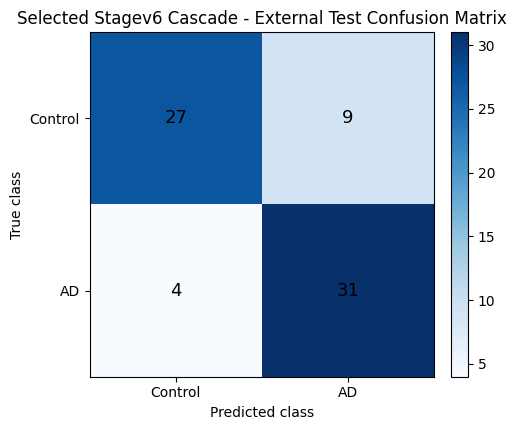

In [9]:
selected_predictions = test_predictions.loc[test_predictions["model_name"] == selected_model_name].copy()
if selected_predictions.empty:
    audit_fail(f"No external predictions found for selected model: {selected_model_name}")
if selected_predictions["sample_id"].duplicated().any():
    audit_fail("Selected-model external predictions contain duplicate sample_id rows")
if selected_predictions["sample_id"].nunique() != EXPECTED_EXTERNAL_N:
    audit_fail(f"Selected-model external n = {selected_predictions['sample_id'].nunique()}, expected {EXPECTED_EXTERNAL_N}")

cm = confusion_matrix(selected_predictions["y_true"], selected_predictions["y_pred"], labels=[0, 1])
TN_pred, FP_pred, FN_pred, TP_pred = int(cm[0, 0]), int(cm[0, 1]), int(cm[1, 0]), int(cm[1, 1])
reported_counts = tuple(int(selected_row[x]) for x in ["TN", "FP", "FN", "TP"])
if (TN_pred, FP_pred, FN_pred, TP_pred) != reported_counts:
    audit_fail(
        "Selected-model confusion matrix mismatch between prediction CSV and performance report: "
        f"predictions={(TN_pred, FP_pred, FN_pred, TP_pred)}, report={reported_counts}"
    )

summary_lines = [
    "### Selected Stagev6 Cascade - External Summary",
    f"**Selected model name:** `{selected_model_name}`",
    f"**Gate model:** `{selected_row['gate_model_name']}`",
    f"**Branch model:** `{selected_row['branch_model_name']}`",
    f"**External accuracy:** {int(selected_row['external_correct'])} / {int(selected_row['external_n'])} = {selected_row['external_accuracy']:.4f}",
    f"**TN / FP / FN / TP:** {TN_pred} / {FP_pred} / {FN_pred} / {TP_pred}",
    f"**Sensitivity:** {selected_row['external_sensitivity']:.4f}",
    f"**Specificity:** {selected_row['external_specificity']:.4f}",
    f"**Balanced accuracy:** {selected_row['external_balanced_accuracy']:.4f}",
    f"**F1:** {selected_row['external_f1']:.4f}",
    f"**MCC:** {selected_row['external_mcc']:.4f}",
    f"**ROC-AUC:** {selected_row['external_roc_auc']:.4f}",
    f"**PR-AUC:** {selected_row['external_pr_auc']:.4f}",
]
display(Markdown("\n\n".join(summary_lines)))

cm_df = pd.DataFrame(cm, index=["true Control", "true AD"], columns=["predicted Control", "predicted AD"])
display_compact(cm_df)

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["Control", "AD"])
ax.set_yticks([0, 1], labels=["Control", "AD"])
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Selected Stagev6 Cascade - External Test Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=13, color="black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
savefig(FIG_DIR / "ipy_fig06_selected_external_confusion_matrix.png")


## 3. External accuracy distribution across all 144 cascades

External accuracy is the sole primary axis in this section.


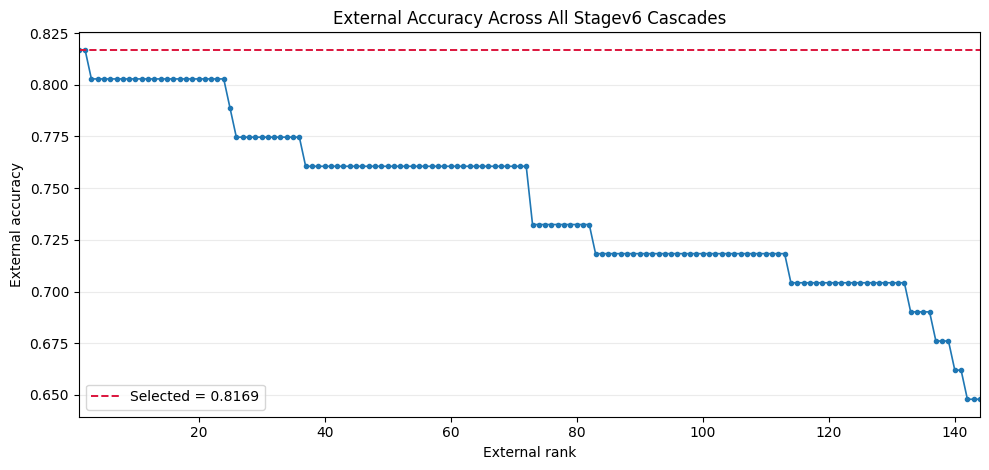

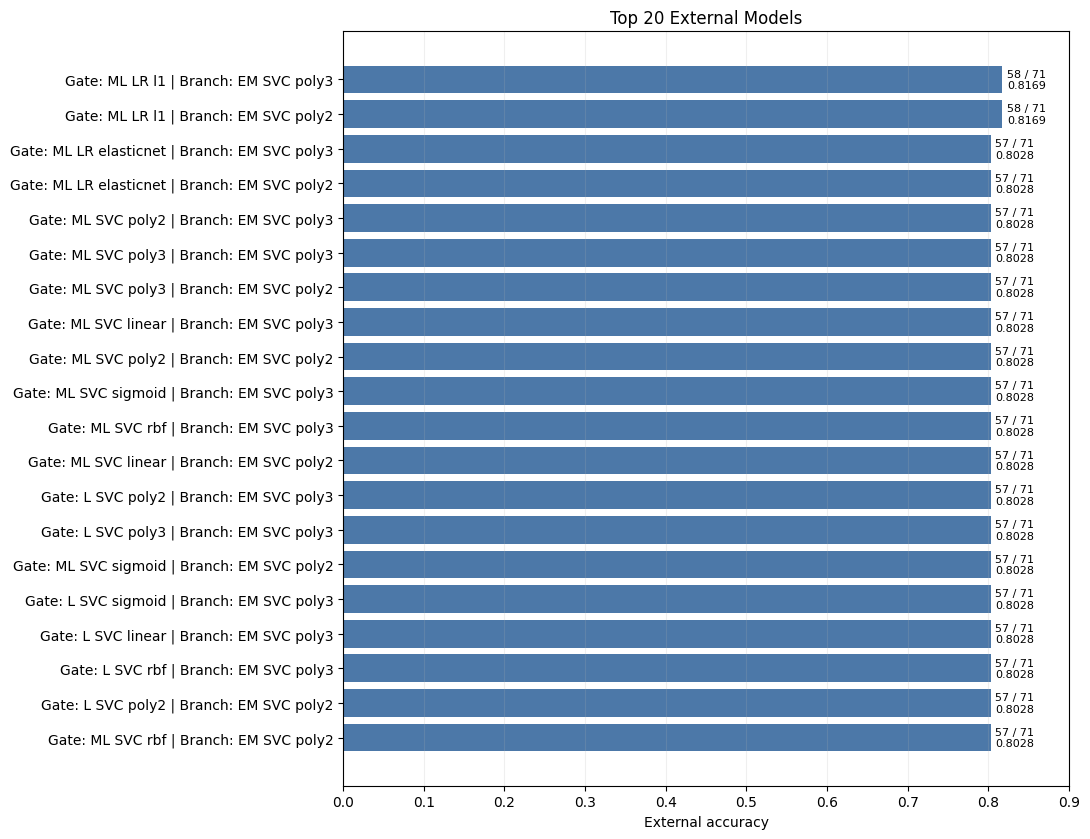

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(external_ranking_all["rank"], external_ranking_all["external_accuracy"], marker="o", linewidth=1.2, markersize=3)
ax.axhline(float(selected_row["external_accuracy"]), color="crimson", linestyle="--", linewidth=1.4, label=f"Selected = {selected_row['external_accuracy']:.4f}")
ax.set_xlabel("External rank")
ax.set_ylabel("External accuracy")
ax.set_title("External Accuracy Across All Stagev6 Cascades")
ax.set_xlim(1, len(external_ranking_all))
ax.grid(axis="y", alpha=0.25)
ax.legend()
savefig(FIG_DIR / "ipy_fig01_external_accuracy_all_cascades.png")

top20 = external_ranking_all.head(20).iloc[::-1].copy()
top20["short_name"] = top20["model_name"].map(compact_model_name)
fig, ax = plt.subplots(figsize=(11, 8.5))
bars = ax.barh(top20["short_name"], top20["external_accuracy"], color="#4C78A8")
ax.set_xlabel("External accuracy")
ax.set_ylabel("")
ax.set_title("Top 20 External Models")
ax.set_xlim(0, min(1.0, max(0.9, float(top20["external_accuracy"].max()) + 0.06)))
ax.grid(axis="x", alpha=0.2)
for bar, (_, row) in zip(bars, top20.iterrows()):
    label = f"{int(row['external_correct'])} / {int(row['external_n'])}\n{row['external_accuracy']:.4f}"
    ax.text(bar.get_width() + 0.006, bar.get_y() + bar.get_height() / 2, label, va="center", fontsize=8)
savefig(FIG_DIR / "ipy_fig02_top20_external_models.png")


## 4. External route diagnostics for the selected cascade

This Stagev6-specific diagnostic is restricted to the selected cascade on the external test set.

`nonlate_AD_direct_late_route` is correct for binary AD/control disease classification, but it is not correct late-stage routing. It is reported separately for route auditing.


,true group,n,routed late-direct AD,routed non-late branch,final predicted AD,final predicted control
0,control,36,2,34,9,27
1,early,6,1,5,5,1
2,middle,14,5,9,12,2
3,late,7,6,1,6,1
4,AD_high_MMSE,8,4,4,8,0


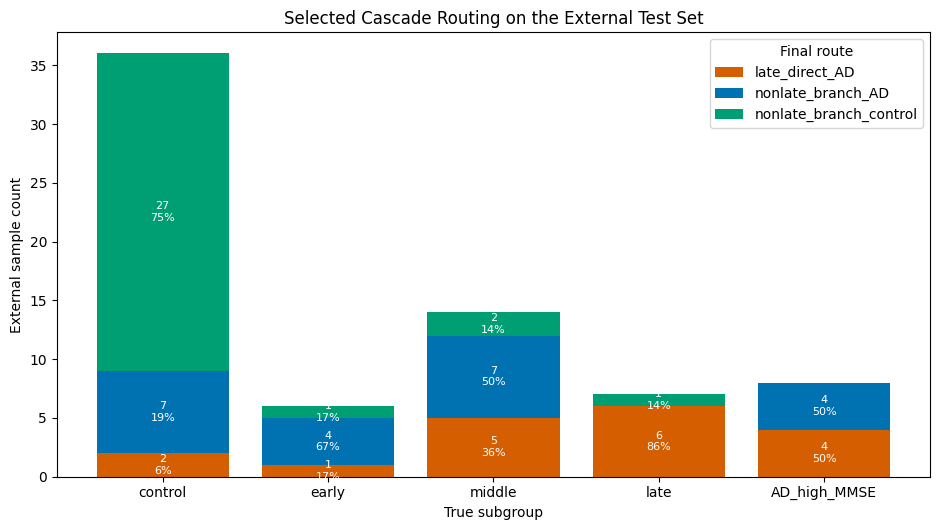

,route_error_type,n
0,correct_late_direct_AD,6
1,late_missed_branch_recovered,0
2,late_missed_final_FN,1
3,control_false_late_route,2
4,control_branch_FP,7
5,nonlate_AD_direct_late_route,10
6,nonlate_AD_branch_FN,3


In [11]:
selected_predictions["true_group"] = pd.Categorical(selected_predictions["severity_group"], categories=EXPECTED_GROUPS, ordered=True)
selected_predictions["route_bucket"] = np.select(
    [
        selected_predictions["final_route"].eq("late_direct_AD"),
        selected_predictions["final_route"].eq("nonlate_branch_AD"),
        selected_predictions["final_route"].eq("nonlate_branch_control"),
    ],
    ["late_direct_AD", "nonlate_branch_AD", "nonlate_branch_control"],
    default=selected_predictions["final_route"].astype(str),
)

route_summary_rows = []
for group in EXPECTED_GROUPS:
    g = selected_predictions[selected_predictions["severity_group"] == group]
    route_summary_rows.append({
        "true group": group,
        "n": len(g),
        "routed late-direct AD": int(g["final_route"].eq("late_direct_AD").sum()),
        "routed non-late branch": int(g["final_route"].isin(["nonlate_branch_AD", "nonlate_branch_control"]).sum()),
        "final predicted AD": int(g["y_pred"].eq(1).sum()),
        "final predicted control": int(g["y_pred"].eq(0).sum()),
    })
external_route_summary = pd.DataFrame(route_summary_rows)
display_compact(external_route_summary)

route_plot = selected_predictions.groupby(["severity_group", "route_bucket"], observed=False).size().unstack(fill_value=0)
for col in ["late_direct_AD", "nonlate_branch_AD", "nonlate_branch_control"]:
    if col not in route_plot.columns:
        route_plot[col] = 0
route_plot = route_plot.loc[EXPECTED_GROUPS, ["late_direct_AD", "nonlate_branch_AD", "nonlate_branch_control"]]
route_prop = route_plot.div(route_plot.sum(axis=1).replace(0, np.nan), axis=0)

fig, ax = plt.subplots(figsize=(9.5, 5.4))
bottom = np.zeros(len(route_plot))
colors = {"late_direct_AD": "#D55E00", "nonlate_branch_AD": "#0072B2", "nonlate_branch_control": "#009E73"}
for col in route_plot.columns:
    vals = route_plot[col].to_numpy()
    ax.bar(route_plot.index, vals, bottom=bottom, label=col, color=colors[col])
    for i, v in enumerate(vals):
        if v > 0:
            pct = route_prop.iloc[i][col] * 100
            ax.text(i, bottom[i] + v / 2, f"{int(v)}\n{pct:.0f}%", ha="center", va="center", color="white", fontsize=8)
    bottom += vals
ax.set_ylabel("External sample count")
ax.set_xlabel("True subgroup")
ax.set_title("Selected Cascade Routing on the External Test Set")
ax.legend(title="Final route")
savefig(FIG_DIR / "ipy_fig03_external_routing_by_subgroup.png")

route_error_types = [
    "correct_late_direct_AD",
    "late_missed_branch_recovered",
    "late_missed_final_FN",
    "control_false_late_route",
    "control_branch_FP",
    "nonlate_AD_direct_late_route",
    "nonlate_AD_branch_FN",
]
route_error_diagnostics_selected = pd.DataFrame({
    "route_error_type": route_error_types,
    "n": [int(selected_predictions["route_error_type"].eq(t).sum()) for t in route_error_types],
})
display_compact(route_error_diagnostics_selected)


## 5. External error-case audit

Only selected-cascade external errors are audited here. Counts and sample listings are descriptive only.


In [12]:
error_cols = [
    "sample_id", "y_true", "severity_group", "mmse", "y_pred", "correct", "p_late", "late_route",
    "p_ad_given_nonlate", "p_ad_mixture", "final_route", "route_error_type",
]
selected_errors = selected_predictions.loc[selected_predictions["correct"].eq(0), error_cols].copy()
selected_errors = selected_errors.rename(columns={"y_true": "true_label", "severity_group": "true_stage_group"})
selected_errors = selected_errors.sort_values(["route_error_type", "true_stage_group", "sample_id"]).reset_index(drop=True)
display_compact(selected_errors)

error_categories = {
    "false positives": selected_predictions[(selected_predictions["y_true"].eq(0)) & (selected_predictions["y_pred"].eq(1))],
    "false negatives": selected_predictions[(selected_predictions["y_true"].eq(1)) & (selected_predictions["y_pred"].eq(0))],
    "control falsely routed to late": selected_predictions[selected_predictions["route_error_type"].eq("control_false_late_route")],
    "late samples missed by gate": selected_predictions[selected_predictions["route_error_type"].isin(["late_missed_branch_recovered", "late_missed_final_FN"])],
    "non-late AD samples directly routed as late": selected_predictions[selected_predictions["route_error_type"].eq("nonlate_AD_direct_late_route")],
}
for name, df in error_categories.items():
    display(Markdown(f"**{name}: {len(df)} sample(s)**"))
    cols = ["sample_id", "y_true", "severity_group", "mmse", "y_pred", "correct", "p_late", "late_route", "p_ad_given_nonlate", "p_ad_mixture", "final_route", "route_error_type"]
    display_compact(df[cols].sort_values(["severity_group", "sample_id"]).reset_index(drop=True))


,sample_id,true_label,true_stage_group,mmse,y_pred,correct,p_late,late_route,p_ad_given_nonlate,p_ad_mixture,final_route,route_error_type
0,TEST_0022,0,control,30,1,0,0.448601,0,0.840275,0.911928,nonlate_branch_AD,control_branch_FP
1,TEST_0024,0,control,29,1,0,0.076957,0,0.969002,0.971388,nonlate_branch_AD,control_branch_FP
2,TEST_0030,0,control,27,1,0,0.488127,0,0.954410,0.976664,nonlate_branch_AD,control_branch_FP
3,TEST_0037,0,control,27,1,0,0.094968,0,0.902371,0.911642,nonlate_branch_AD,control_branch_FP
4,TEST_0058,0,control,28,1,0,0.260875,0,0.952206,0.964674,nonlate_branch_AD,control_branch_FP
5,TEST_0060,0,control,28,1,0,0.130796,0,0.777112,0.806265,nonlate_branch_AD,control_branch_FP
6,TEST_0069,0,control,29,1,0,0.087443,0,0.968997,0.971708,nonlate_branch_AD,control_branch_FP
7,TEST_0013,0,control,29,1,0,0.530523,1,0.551974,0.789662,late_direct_AD,control_false_late_route
8,TEST_0027,0,control,28,1,0,0.630114,1,0.894185,0.960860,late_direct_AD,control_false_late_route
9,TEST_0033,1,late,10,0,0,0.379780,0,0.237816,0.527278,nonlate_branch_control,late_missed_final_FN


**false positives: 9 sample(s)**

,sample_id,y_true,severity_group,mmse,y_pred,correct,p_late,late_route,p_ad_given_nonlate,p_ad_mixture,final_route,route_error_type
0,TEST_0013,0,control,29,1,0,0.530523,1,0.551974,0.789662,late_direct_AD,control_false_late_route
1,TEST_0022,0,control,30,1,0,0.448601,0,0.840275,0.911928,nonlate_branch_AD,control_branch_FP
2,TEST_0024,0,control,29,1,0,0.076957,0,0.969002,0.971388,nonlate_branch_AD,control_branch_FP
3,TEST_0027,0,control,28,1,0,0.630114,1,0.894185,0.960860,late_direct_AD,control_false_late_route
4,TEST_0030,0,control,27,1,0,0.488127,0,0.954410,0.976664,nonlate_branch_AD,control_branch_FP
5,TEST_0037,0,control,27,1,0,0.094968,0,0.902371,0.911642,nonlate_branch_AD,control_branch_FP
6,TEST_0058,0,control,28,1,0,0.260875,0,0.952206,0.964674,nonlate_branch_AD,control_branch_FP
7,TEST_0060,0,control,28,1,0,0.130796,0,0.777112,0.806265,nonlate_branch_AD,control_branch_FP
8,TEST_0069,0,control,29,1,0,0.087443,0,0.968997,0.971708,nonlate_branch_AD,control_branch_FP


**false negatives: 4 sample(s)**

,sample_id,y_true,severity_group,mmse,y_pred,correct,p_late,late_route,p_ad_given_nonlate,p_ad_mixture,final_route,route_error_type
0,TEST_0041,1,early,23,0,0,0.226481,0,0.042533,0.259382,nonlate_branch_control,nonlate_AD_branch_FN
1,TEST_0033,1,late,10,0,0,0.379780,0,0.237816,0.527278,nonlate_branch_control,late_missed_final_FN
2,TEST_0017,1,middle,16,0,0,0.399335,0,0.184264,0.510016,nonlate_branch_control,nonlate_AD_branch_FN
3,TEST_0046,1,middle,20,0,0,0.255015,0,0.420489,0.568273,nonlate_branch_control,nonlate_AD_branch_FN


...

,sample_id,y_true,severity_group,mmse,y_pred,correct,p_late,late_route,p_ad_given_nonlate,p_ad_mixture,final_route,route_error_type
0,TEST_0013,0,control,29,1,0,0.530523,1,0.551974,0.789662,late_direct_AD,control_false_late_route
1,TEST_0027,0,control,28,1,0,0.630114,1,0.894185,0.960860,late_direct_AD,control_false_late_route


**late samples missed by gate: 1 sample(s)**

,sample_id,y_true,severity_group,mmse,y_pred,correct,p_late,late_route,p_ad_given_nonlate,p_ad_mixture,final_route,route_error_type
0,TEST_0033,1,late,10,0,0,0.37978,0,0.237816,0.527278,nonlate_branch_control,late_missed_final_FN


**non-late AD samples directly routed as late: 10 sample(s)**

,sample_id,y_true,severity_group,mmse,y_pred,correct,p_late,late_route,p_ad_given_nonlate,p_ad_mixture,final_route,route_error_type
0,TEST_0011,1,AD_high_MMSE,25,1,1,0.689938,1,0.864021,0.957838,late_direct_AD,nonlate_AD_direct_late_route
1,TEST_0019,1,AD_high_MMSE,30,1,1,0.685919,1,0.987689,0.996133,late_direct_AD,nonlate_AD_direct_late_route
2,TEST_0021,1,AD_high_MMSE,30,1,1,0.541063,1,0.744447,0.882717,late_direct_AD,nonlate_AD_direct_late_route
3,TEST_0065,1,AD_high_MMSE,25,1,1,0.651733,1,0.484157,0.820349,late_direct_AD,nonlate_AD_direct_late_route
4,TEST_0014,1,early,24,1,1,0.731891,1,0.930763,0.981437,late_direct_AD,nonlate_AD_direct_late_route
5,TEST_0008,1,middle,13,1,1,0.571220,1,0.975605,0.989540,late_direct_AD,nonlate_AD_direct_late_route
6,TEST_0029,1,middle,16,1,1,0.550228,1,0.767434,0.895398,late_direct_AD,nonlate_AD_direct_late_route
7,TEST_0032,1,middle,20,1,1,0.632755,1,0.916383,0.969292,late_direct_AD,nonlate_AD_direct_late_route
8,TEST_0040,1,middle,20,1,1,0.641123,1,0.946433,0.980776,late_direct_AD,nonlate_AD_direct_late_route
9,TEST_0070,1,middle,20,1,1,0.798318,1,0.999990,0.999998,late_direct_AD,nonlate_AD_direct_late_route


## 6. External subgroup accuracy

This is disease-classification accuracy by true external subgroup. It is not stage-classification accuracy because Stagev6 outputs `control`, `non-late AD`, or `late-direct AD`, not a full early/middle/late multiclass stage prediction.


,group,n,correct,accuracy,predicted_AD,predicted_control,late_direct_AD,nonlate_branch_AD,nonlate_branch_control
0,control,36,27,0.750000,9,27,2,7,27
1,early,6,5,0.833333,5,1,1,4,1
2,middle,14,12,0.857143,12,2,5,7,2
3,late,7,6,0.857143,6,1,6,0,1
4,AD_high_MMSE,8,8,1.000000,8,0,4,4,0


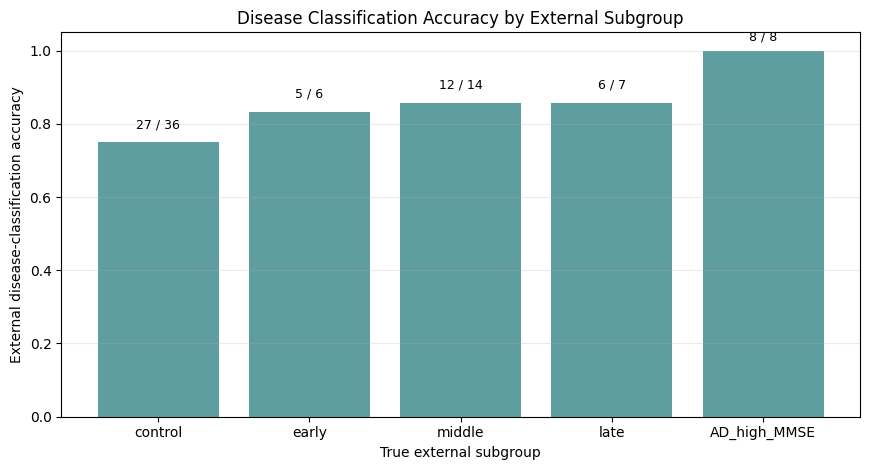

In [13]:
subgroup_rows = []
for group in EXPECTED_GROUPS:
    g = selected_predictions[selected_predictions["severity_group"] == group]
    subgroup_rows.append({
        "group": group,
        "n": len(g),
        "correct": int(g["correct"].sum()),
        "accuracy": float(g["correct"].mean()) if len(g) else np.nan,
        "predicted_AD": int(g["y_pred"].eq(1).sum()),
        "predicted_control": int(g["y_pred"].eq(0).sum()),
        "late_direct_AD": int(g["final_route"].eq("late_direct_AD").sum()),
        "nonlate_branch_AD": int(g["final_route"].eq("nonlate_branch_AD").sum()),
        "nonlate_branch_control": int(g["final_route"].eq("nonlate_branch_control").sum()),
    })
external_subgroup_accuracy = pd.DataFrame(subgroup_rows)
display_compact(external_subgroup_accuracy)

fig, ax = plt.subplots(figsize=(8.8, 4.8))
bars = ax.bar(external_subgroup_accuracy["group"], external_subgroup_accuracy["accuracy"], color="#5F9EA0")
ax.set_ylim(0, 1.05)
ax.set_xlabel("True external subgroup")
ax.set_ylabel("External disease-classification accuracy")
ax.set_title("Disease Classification Accuracy by External Subgroup")
ax.grid(axis="y", alpha=0.25)
for bar, (_, row) in zip(bars, external_subgroup_accuracy.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, min(1.02, row["accuracy"] + 0.03), f"{int(row['correct'])} / {int(row['n'])}", ha="center", va="bottom", fontsize=9)
savefig(FIG_DIR / "ipy_fig04_external_subgroup_accuracy.png")


## 7. Bootstrap external accuracy uncertainty

This section reports the selected cascade's bootstrap external accuracy CI. The histogram uses deterministic resampling of the selected cascade's existing external prediction rows, and the table reports the stored Stagev6 bootstrap CI from the result file.


,point external accuracy,bootstrap mean,bootstrap median,95% CI lower,95% CI upper,bootstrap n
0,0.816901,0.813592,0.816901,0.732394,0.887324,200


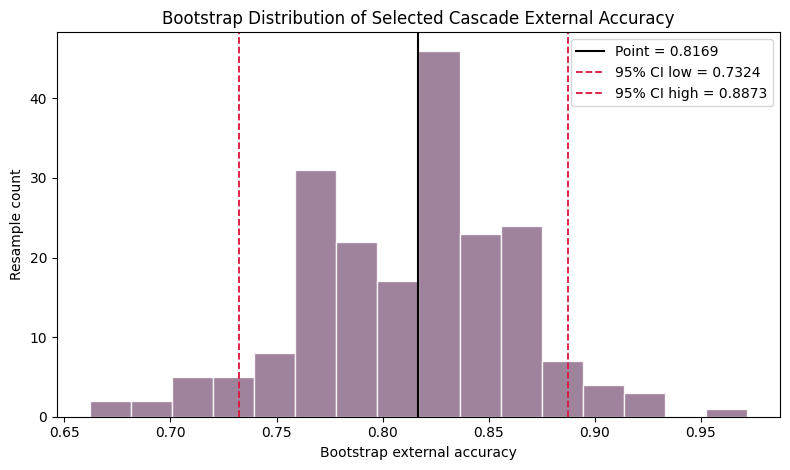

In [14]:
require_columns(bootstrap_ci, ["model_name", "metric", "bootstrap_mean", "ci_low", "ci_high", "n_boot"], "bootstrap CI")
selected_boot_acc = bootstrap_ci[(bootstrap_ci["model_name"].eq(selected_model_name)) & (bootstrap_ci["metric"].eq("accuracy"))]
if selected_boot_acc.empty:
    audit_fail(f"No bootstrap accuracy CI row found for selected model: {selected_model_name}")
selected_boot_acc = selected_boot_acc.iloc[0]
point_external_accuracy = float(selected_row["external_accuracy"])
bootstrap_n = int(selected_boot_acc["n_boot"])

rng = np.random.default_rng(20260621)
y_true = selected_predictions["y_true"].to_numpy()
y_pred = selected_predictions["y_pred"].to_numpy()
boot_acc_values = np.empty(bootstrap_n)
for i in range(bootstrap_n):
    idx = rng.integers(0, len(y_true), len(y_true))
    boot_acc_values[i] = np.mean(y_true[idx] == y_pred[idx])

bootstrap_summary = pd.DataFrame([{
    "point external accuracy": point_external_accuracy,
    "bootstrap mean": float(selected_boot_acc["bootstrap_mean"]),
    "bootstrap median": float(np.median(boot_acc_values)),
    "95% CI lower": float(selected_boot_acc["ci_low"]),
    "95% CI upper": float(selected_boot_acc["ci_high"]),
    "bootstrap n": bootstrap_n,
}])
display_compact(bootstrap_summary)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(boot_acc_values, bins=16, color="#8E6C8A", alpha=0.85, edgecolor="white")
ax.axvline(point_external_accuracy, color="black", linestyle="-", linewidth=1.5, label=f"Point = {point_external_accuracy:.4f}")
ax.axvline(float(selected_boot_acc["ci_low"]), color="crimson", linestyle="--", linewidth=1.3, label=f"95% CI low = {float(selected_boot_acc['ci_low']):.4f}")
ax.axvline(float(selected_boot_acc["ci_high"]), color="crimson", linestyle="--", linewidth=1.3, label=f"95% CI high = {float(selected_boot_acc['ci_high']):.4f}")
ax.set_xlabel("Bootstrap external accuracy")
ax.set_ylabel("Resample count")
ax.set_title("Bootstrap Distribution of Selected Cascade External Accuracy")
ax.legend()
savefig(FIG_DIR / "ipy_fig05_selected_external_bootstrap_accuracy.png")


## 8. CV as secondary audit only

Cross-validation is shown only as an internal stability reference. The notebook's selected model and primary result display are determined by external accuracy.


In [15]:
require_columns(cv_summary, ["model_name", "cv_accuracy", "cv_balanced_accuracy"], "CV summary")
require_columns(generalization_gap, ["model_name", "cv_accuracy", "external_accuracy", "accuracy_gap"], "generalization gap")
cv_selected = cv_summary[cv_summary["model_name"].eq(selected_model_name)]
if cv_selected.empty:
    audit_fail(f"No CV summary row found for selected model: {selected_model_name}")
cv_selected = cv_selected.iloc[0]
gap_selected = generalization_gap[generalization_gap["model_name"].eq(selected_model_name)]
gap_value = float(gap_selected.iloc[0]["accuracy_gap"]) if not gap_selected.empty else float(cv_selected["cv_accuracy"] - selected_row["external_accuracy"])

cv_secondary_summary = pd.DataFrame([{
    "model_name": selected_model_name,
    "CV/OOF accuracy": float(cv_selected["cv_accuracy"]),
    "external accuracy": float(selected_row["external_accuracy"]),
    "generalization gap": gap_value,
    "CV balanced accuracy": float(cv_selected["cv_balanced_accuracy"]),
    "external balanced accuracy": float(selected_row["external_balanced_accuracy"]),
}])
display_compact(cv_secondary_summary)

top10_cv_audit = top10_external_models[["model_name", "external_accuracy"]].merge(
    cv_summary[["model_name", "cv_accuracy"]], on="model_name", how="left"
)
if top10_cv_audit["cv_accuracy"].isna().any():
    audit_fail("Missing CV accuracy for at least one Top 10 external model")
top10_cv_audit["external_minus_cv_accuracy"] = top10_cv_audit["external_accuracy"] - top10_cv_audit["cv_accuracy"]
display_compact(top10_cv_audit, ["model_name", "external_accuracy", "cv_accuracy", "external_minus_cv_accuracy"])


,model_name,CV/OOF accuracy,external accuracy,generalization gap,CV balanced accuracy,external balanced accuracy
0,cascade__gate__middle_late__lr__l1__TO__branch__early_middle__svc__poly3,0.813253,0.816901,-0.003648,0.811363,0.817857


,model_name,external_accuracy,cv_accuracy,external_minus_cv_accuracy
0,cascade__gate__middle_late__lr__l1__TO__branch__early_middle__svc__poly3,0.816901,0.813253,0.003648
1,cascade__gate__middle_late__lr__l1__TO__branch__early_middle__svc__poly2,0.816901,0.831325,-0.014424
2,cascade__gate__middle_late__lr__elasticnet__TO__branch__early_middle__svc__poly3,0.802817,0.819277,-0.016460
3,cascade__gate__middle_late__lr__elasticnet__TO__branch__early_middle__svc__poly2,0.802817,0.843373,-0.040557
4,cascade__gate__middle_late__svc__poly2__TO__branch__early_middle__svc__poly3,0.802817,0.849398,-0.046581
5,cascade__gate__middle_late__svc__poly3__TO__branch__early_middle__svc__poly3,0.802817,0.849398,-0.046581
6,cascade__gate__middle_late__svc__poly3__TO__branch__early_middle__svc__poly2,0.802817,0.873494,-0.070677
7,cascade__gate__middle_late__svc__linear__TO__branch__early_middle__svc__poly3,0.802817,0.849398,-0.046581
8,cascade__gate__middle_late__svc__poly2__TO__branch__early_middle__svc__poly2,0.802817,0.873494,-0.070677
9,cascade__gate__middle_late__svc__sigmoid__TO__branch__early_middle__svc__poly3,0.802817,0.849398,-0.046581


## 9. Final external-test-first conclusion


In [16]:
late_direct_correct_count = int(selected_predictions["route_error_type"].eq("correct_late_direct_AD").sum())
control_false_late_route_count = int(selected_predictions["route_error_type"].eq("control_false_late_route").sum())
late_missed_final_fn_count = int(selected_predictions["route_error_type"].eq("late_missed_final_FN").sum())

final_summary = f"""
Selected Stagev6 cascade:  
`{selected_model_name}`

External test performance:  
{int(selected_row['external_correct'])} / {int(selected_row['external_n'])} = {selected_row['external_accuracy']:.4f}  
TN={TN_pred}, FP={FP_pred}, FN={FN_pred}, TP={TP_pred}

Routing summary:  
{late_direct_correct_count} true late samples were directly routed as late-stage AD.  
{control_false_late_route_count} control samples were incorrectly routed to late-stage AD.  
{late_missed_final_fn_count} late samples were ultimately classified as control.

Interpretation boundary:  
This notebook reports external held-out performance within the current Stagev6 model-selection workflow. It does not claim an independently untouched final-test estimate after external-ranking selection.
"""
display(Markdown(final_summary))
print("Stagev6 external-test-first result audit completed successfully.")



Selected Stagev6 cascade:  
`cascade__gate__middle_late__lr__l1__TO__branch__early_middle__svc__poly3`

External test performance:  
58 / 71 = 0.8169  
TN=27, FP=9, FN=4, TP=31

Routing summary:  
6 true late samples were directly routed as late-stage AD.  
2 control samples were incorrectly routed to late-stage AD.  
1 late samples were ultimately classified as control.

Interpretation boundary:  
This notebook reports external held-out performance within the current Stagev6 model-selection workflow. It does not claim an independently untouched final-test estimate after external-ranking selection.


Stagev6 external-test-first result audit completed successfully.
